In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math

# wavelength
lam = 852.3e-9  # [m]

# gaussian beam
def gaussian_beam_radius(z, w0, z0):
    zR = np.pi * w0**2 / lam
    return w0 * np.sqrt(1 + ((z - z0) / zR)**2)

# beam divergence
def linear(z, theta, r0):
    return theta * z + r0

def truncate_n(x,n):
    return math.floor(x * 10**n) / 10**n

## Fitting

VBGレーザー(new cooling)から出射したレーザー光を直接測定した。　


fitting_result_vertical: w0=3.46e-04[m], z0=8.71e-02[m]
fitting_result_horizontal: w0=1.59e-04[m], z0=-3.74e-02[m]
Rayleigh_length_vertical: zR=4.42e-01[m]
Rayleigh_length_horizontal: zR=9.27e-02[m]


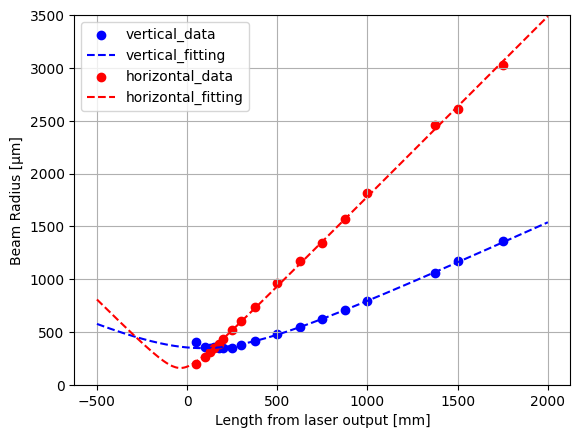

In [10]:
z = np.array([2, 4, 5, 6, 7, 8, 10, 12, 15, 20, 25, 30, 35, 40, 55, 60, 70])*25e-3 # [m]
radius_X = np.array([813,713,695,719,690,700,699,756,832,967,1099,1241,1410,1579,2111,2340,2730])/2*1e-6 # [m]
radius_Y = np.array([390,529,611,690,772,871,1034,1205,1466,1925,2348,2690,3145,3625,4911,5215,6050])/2*1e-6 # [m]

# initial value
p0 = [1e-4, 0] # w0, z0

# fitting (gaussian beam)
popt_X, pcov_X = curve_fit(gaussian_beam_radius, z, radius_X, p0=p0)
popt_Y, pcov_Y = curve_fit(gaussian_beam_radius, z, radius_Y, p0=p0)
w0_X, z0_X = popt_X
w0_Y, z0_Y = popt_Y
zR_X = np.pi*w0_X**2/lam
zR_Y = np.pi*w0_Y**2/lam

# q parameter at laser output
q0_X = -1*z0_X + 1j*zR_X
q0_Y = -1*z0_Y + 1j*zR_Y

print(f"fitting_result_vertical: w0={w0_X:.2e}[m], z0={z0_X:.2e}[m]")
print(f"fitting_result_horizontal: w0={w0_Y:.2e}[m], z0={z0_Y:.2e}[m]")
print(f"Rayleigh_length_vertical: zR={zR_X:.2e}[m]")
print(f"Rayleigh_length_horizontal: zR={zR_Y:.2e}[m]")

z_fit = np.linspace(-0.5, 2, 300)
X_fit = gaussian_beam_radius(z_fit, w0_X, z0_X)
Y_fit = gaussian_beam_radius(z_fit, w0_Y, z0_Y)

# plot
plt.scatter(z*1e3, radius_X *1e6, label="vertical_data", color="blue")
plt.plot(z_fit*1e3, X_fit*1e6, label="vertical_fitting", color="blue", linestyle="--")
plt.scatter(z*1e3, radius_Y*1e6, label="horizontal_data", color="red")
plt.plot(z_fit*1e3, Y_fit*1e6, label="horizontal_fitting", color="red", linestyle="--")
plt.ylim(0,3500)
plt.xlabel("Length from laser output [mm]")
plt.ylabel("Beam Radius [μm]")
plt.legend()
plt.grid(True)
plt.show()

## lens selection

AOM前後にレンズを置いた場合の計算を行った。  
d1: レーザー出射位置(z=0)からlens1までの距離  
d2: lens1からlens2までの距離  

q2_X= (-0.18786981228181246+0.04783434713207538j)
q2_Y= (-0.231846003752905+0.2384749996236971j)


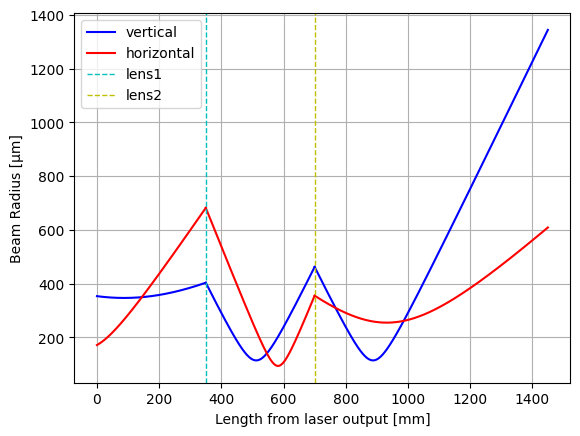

q_X  at z=1100 mm: (0.21213018771818767+0.04783434713207538j)
q_Y  at z=1100 mm: (0.16815399624709512+0.2384749996236971j)


In [11]:
d1 = 350e-3 #[m]
f1 = 150e-3 #[m]

d2 = 350e-3 #[m]

f2 = 100e-3 #[m]
#d3 = 250e-3 #[m]
d3 = 750e-3 #[m]

Md1 = np.array([[1, d1], [0, 1]])
Mf1 = np.array([[1, 0], [-1/f1, 1]])
M = np.matmul(Mf1, Md1)
A = M[0, 0]
B = M[0, 1]
C = M[1, 0]
D = M[1, 1]

q1_X = (A*q0_X+B) / (C*q0_X+D)
z0_X_1 = -q1_X.real
zR_X_1 = q1_X.imag
w0_X_1 = np.sqrt(lam/np.pi*zR_X_1)

q1_Y = (A*q0_Y+B) / (C*q0_Y+D)
z0_Y_1 = -q1_Y.real
zR_Y_1 = q1_Y.imag
w0_Y_1 = np.sqrt(lam/np.pi*zR_Y_1)

Md2 = np.array([[1, d2], [0, 1]])
Mf2 = np.array([[1, 0], [-1/f2, 1]])
M = np.matmul(Mf2, Md2)
A = M[0, 0]
B = M[0, 1]
C = M[1, 0]
D = M[1, 1]

q2_X = (A*q1_X+B) / (C*q1_X+D)
z0_X_2 = -q2_X.real
zR_X_2 = q2_X.imag
w0_X_2 = np.sqrt(lam/np.pi*zR_X_2)
print("q2_X=", q2_X)

q2_Y = (A*q1_Y+B) / (C*q1_Y+D)
z0_Y_2 = -q2_Y.real
zR_Y_2 = q2_Y.imag
w0_Y_2 = np.sqrt(lam/np.pi*zR_Y_2)
print("q2_Y=", q2_Y)

z_fit = np.linspace(0,d1,1000)
X_fit = gaussian_beam_radius(z_fit, w0_X, z0_X)
Y_fit = gaussian_beam_radius(z_fit, w0_Y, z0_Y)

z_fit_1= np.linspace(d1, d1+d2, 1000)
X_fit_1 = gaussian_beam_radius(z_fit_1-d1, w0_X_1, z0_X_1)
Y_fit_1 = gaussian_beam_radius(z_fit_1-d1, w0_Y_1, z0_Y_1)

z_fit_2 = np.linspace(d1+d2, d1+d2+d3, 1000)
X_fit_2 = gaussian_beam_radius(z_fit_2-(d1+d2), w0_X_2, z0_X_2)
Y_fit_2 = gaussian_beam_radius(z_fit_2-(d1+d2), w0_Y_2, z0_Y_2)

# plot
plt.plot(z_fit*1e3, X_fit*1e6, label="vertical", color="b", linestyle="-")
plt.plot(z_fit_1*1e3, X_fit_1*1e6, color="b", linestyle="-")
plt.plot(z_fit_2*1e3, X_fit_2*1e6, color="b", linestyle="-")

plt.plot(z_fit*1e3, Y_fit*1e6, label="horizontal", color="r", linestyle="-")
plt.plot(z_fit_1*1e3, Y_fit_1*1e6, color="r", linestyle="-")
plt.plot(z_fit_2*1e3, Y_fit_2*1e6, color="r", linestyle="-")

plt.axvline(x=d1*1e3, color='c', linestyle='--', linewidth=1, label="lens1")
#plt.axvline(x=650, color='m', linestyle='--', linewidth=1, label="AOM")
plt.axvline(x=(d1+d2)*1e3, color='y', linestyle='--', linewidth=1, label="lens2")
#plt.axvline(x=1000, color='black', linestyle='--', linewidth=1, label="coupler")

plt.xlabel("Length from laser output [mm]")
plt.ylabel("Beam Radius [μm]")
plt.legend()
plt.grid(True)
plt.show()


# --- 以下を追記 ---
# 全長 1100 mm の点での q を計算
z_query = 1100e-3  # [m]
# レンズ２通過点までは d1+d2 なので、その先を dz として伝搬
dz_after_lens2 = z_query - (d1 + d2)

# q2_X, q2_Y はレンズ２直後の q
q3_X_at_1100 = q2_X + dz_after_lens2
q3_Y_at_1100 = q2_Y + dz_after_lens2

print(f"q_X  at z=1100 mm: {q3_X_at_1100}")
print(f"q_Y  at z=1100 mm: {q3_Y_at_1100}")


d2(レンズ間の距離)を少し変えて、いい感じかどうか確認する。

q2_X= (-0.189083814644052+0.04845095142965373j)
q2_Y= (-0.2607681496671448+0.2264182218395673j)


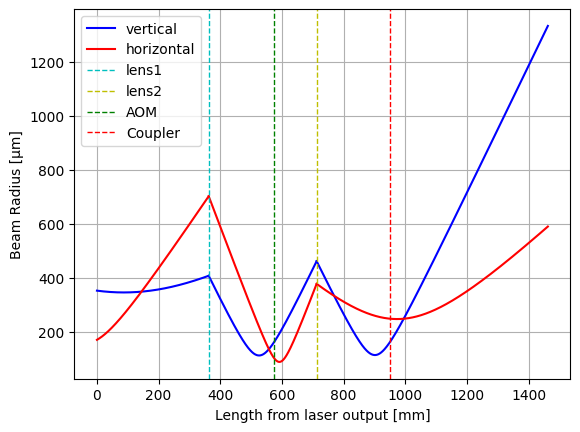

In [12]:
d1 = 362.5e-3 #[m]
f1 = 150e-3 #[m]

d2 = 350e-3 #[m]

f2 = 100e-3 #[m]
#d3 = 250e-3 #[m]



Md1 = np.array([[1, d1], [0, 1]])
Mf1 = np.array([[1, 0], [-1/f1, 1]])
M = np.matmul(Mf1, Md1)
A = M[0, 0]
B = M[0, 1]
C = M[1, 0]
D = M[1, 1]

q1_X = (A*q0_X+B) / (C*q0_X+D)
z0_X_1 = -q1_X.real
zR_X_1 = q1_X.imag
w0_X_1 = np.sqrt(lam/np.pi*zR_X_1)

q1_Y = (A*q0_Y+B) / (C*q0_Y+D)
z0_Y_1 = -q1_Y.real
zR_Y_1 = q1_Y.imag
w0_Y_1 = np.sqrt(lam/np.pi*zR_Y_1)

Md2 = np.array([[1, d2], [0, 1]])
Mf2 = np.array([[1, 0], [-1/f2, 1]])
M = np.matmul(Mf2, Md2)
A = M[0, 0]
B = M[0, 1]
C = M[1, 0]
D = M[1, 1]

q2_X = (A*q1_X+B) / (C*q1_X+D)
z0_X_2 = -q2_X.real
zR_X_2 = q2_X.imag
w0_X_2 = np.sqrt(lam/np.pi*zR_X_2)
print("q2_X=", q2_X)

q2_Y = (A*q1_Y+B) / (C*q1_Y+D)
z0_Y_2 = -q2_Y.real
zR_Y_2 = q2_Y.imag
w0_Y_2 = np.sqrt(lam/np.pi*zR_Y_2)
print("q2_Y=", q2_Y)

z_fit = np.linspace(0,d1,1000)
X_fit = gaussian_beam_radius(z_fit, w0_X, z0_X)
Y_fit = gaussian_beam_radius(z_fit, w0_Y, z0_Y)

z_fit_1= np.linspace(d1, d1+d2, 1000)
X_fit_1 = gaussian_beam_radius(z_fit_1-d1, w0_X_1, z0_X_1)
Y_fit_1 = gaussian_beam_radius(z_fit_1-d1, w0_Y_1, z0_Y_1)

z_fit_2 = np.linspace(d1+d2, d1+d2+d3, 1000)
X_fit_2 = gaussian_beam_radius(z_fit_2-(d1+d2), w0_X_2, z0_X_2)
Y_fit_2 = gaussian_beam_radius(z_fit_2-(d1+d2), w0_Y_2, z0_Y_2)

# plot
plt.plot(z_fit*1e3, X_fit*1e6, label="vertical", color="b", linestyle="-")
plt.plot(z_fit_1*1e3, X_fit_1*1e6, color="b", linestyle="-")
plt.plot(z_fit_2*1e3, X_fit_2*1e6, color="b", linestyle="-")

plt.plot(z_fit*1e3, Y_fit*1e6, label="horizontal", color="r", linestyle="-")
plt.plot(z_fit_1*1e3, Y_fit_1*1e6, color="r", linestyle="-")
plt.plot(z_fit_2*1e3, Y_fit_2*1e6, color="r", linestyle="-")

plt.axvline(x=d1*1e3, color='c', linestyle='--', linewidth=1, label="lens1")
#plt.axvline(x=650, color='m', linestyle='--', linewidth=1, label="AOM")
plt.axvline(x=(d1+d2)*1e3, color='y', linestyle='--', linewidth=1, label="lens2")
#plt.axvline(x=1000, color='black', linestyle='--', linewidth=1, label="coupler")

plt.axvline(x=575, color='g', linestyle='--', linewidth=1, label="AOM")
#plt.axvline(x=650, color='green', linestyle='--', linewidth=1, label="AOM")
plt.axvline(x=950, color='r', linestyle='--', linewidth=1, label="Coupler")
#plt.axvline(x=1000, color='red', linestyle='--', linewidth=1, label="coupler")

plt.xlabel("Length from laser output [mm]")
plt.ylabel("Beam Radius [μm]")
plt.legend()
plt.grid(True)
plt.show()

z=1100(カップラーの位置)でのビーム径の測定

カップラーレンズを入れてビーム径がxyともに絞られるかを考える
f3はカップラーレンズの焦点距離

カップラーの位置を変えて、発散角を計算する。
これがファイバーのNA(開口数)に近いものを探す。なお、今回使用するファイバーのNAは(0.1-0.14[rad])

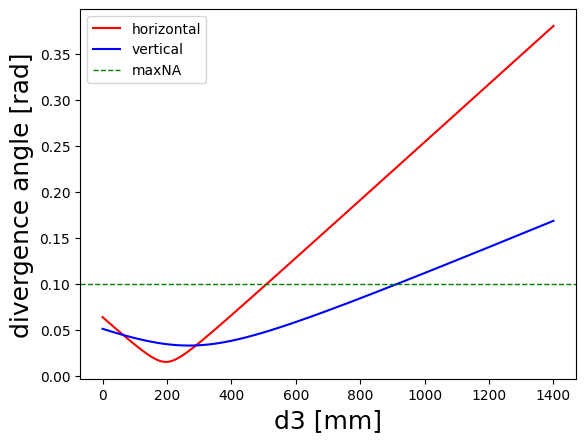

In [13]:
import numpy as np
import matplotlib.pyplot as plt

f3 = 7.5e-3  # [m]

# d3の距離を振って最適な値を探索する。
d3_list = np.linspace(0, 1400*1e-3, 700)
d3_list = d3_list
theta_X_list = []
theta_Y_list = []

for d3 in d3_list:
    Md3 = np.array([[1, d3], [0, 1]])
    Mf3 = np.array([[1, 0], [-1/f3, 1]])
    M = np.matmul(Mf3, Md3)
    A = M[0, 0]
    B = M[0, 1]
    C = M[1, 0]
    D = M[1, 1]

    q3_X = (A*q2_X+B) / (C*q2_X+D)
    z0_X_3 = -q3_X.real
    zR_X_3 = q3_X.imag
    w0_X_3 = np.sqrt(lam/np.pi*zR_X_3)
    theta_X = lam/(np.pi*w0_X_3)
    theta_X_list.append(theta_X)

    q3_Y = (A*q2_Y+B) / (C*q2_Y+D)
    z0_Y_3 = -q3_Y.real
    zR_Y_3 = q3_Y.imag
    w0_Y_3 = np.sqrt(lam/np.pi*zR_Y_3)
    theta_Y = lam/(np.pi*w0_Y_3)
    theta_Y_list.append(theta_Y)


plt.plot(d3_list*1e3, theta_X_list, label="horizontal", color="r", linestyle="-")
plt.plot(d3_list*1e3, theta_Y_list, label="vertical", color="b", linestyle="-")
plt.axhline(y=0.10, color='g', linestyle='--', linewidth=1, label="maxNA")
#plt.axhline(y=0.14, color='r', linestyle='--', linewidth=1, label="maxNA")
plt.xlabel("d3 [mm]", fontsize=18)
plt.ylabel("divergence angle [rad]", fontsize=18)
plt.legend()
plt.show()


上のグラフのmaxNA以下であればビームがコリメートレンズによって絞られた際にファイバーに入射できる。
従って、d2からの距離が約500mm以下であればこの条件を満たす。
これはひとつ前のBeamRadiusのグラフにおいて1200よりd2に近い位置にカップラーを置けばよく、
縦横のビーム径が一致している1000mmの周囲もこれに含まれている

q2_X= (-0.23333274847814917+0.00013962389032387982j)
q3_X= (-0.1538453452457086+0.0001858895390963601j)


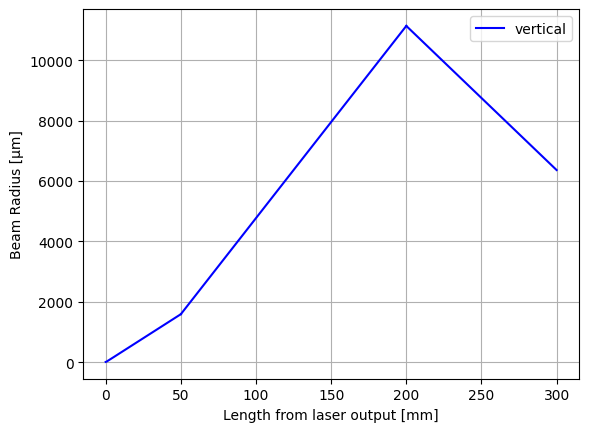

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math

# gaussian beam
def gaussian_beam_radius(z, w0, z0):
    zR = np.pi * w0**2 / lam
    return w0 * np.sqrt(1 + ((z - z0) / zR)**2)


# 初期設定
d1 = 50.0e-3  # [m]
f1 = -50e-3  # [m]
d2 = 150e-3  # [m]
f2 = 100e-3  # [m]
d3 = 100e-3  # [m]
w0_X = 10e-6  # [m]
lam = 1.0e-6  # [m]
z0_X = 0.0  # [m]
zR_X = np.pi*w0_X**2/lam

q0_X = -1*z0_X + 1j*zR_X



Md1 = np.array([[1, d1], [0, 1]])
Mf1 = np.array([[1, 0], [-1/f1, 1]])
M = np.matmul(Mf1, Md1)
A = M[0, 0]
B = M[0, 1]
C = M[1, 0]
D = M[1, 1]

q1_X = (A*q0_X+B) / (C*q0_X+D)
z0_X_1 = -q1_X.real
zR_X_1 = q1_X.imag
w0_X_1 = np.sqrt(lam/np.pi*zR_X_1)

Md2 = np.array([[1, d2], [0, 1]])
Mf2 = np.array([[1, 0], [-1/f2, 1]])
M = np.matmul(Mf2, Md2)
A = M[0, 0]
B = M[0, 1]
C = M[1, 0]
D = M[1, 1]

q2_X = (A*q1_X+B) / (C*q1_X+D)
z0_X_2 = -q2_X.real
zR_X_2 = q2_X.imag
w0_X_2 = np.sqrt(lam/np.pi*zR_X_2)
print("q2_X=", q2_X)

Md3 = np.array([[1, d3], [0, 1]])
Mf3 = np.array([[1, 0], [1, 1]])
M = np.matmul(Mf3, Md3)
A = M[0, 0]
B = M[0, 1]
C = M[1, 0]
D = M[1, 1]

q3_X = (A*q2_X+B) / (C*q2_X+D)
z0_X_3 = -q3_X.real
zR_X_3 = q3_X.imag
print("q3_X=", q3_X)

z_fit = np.linspace(0,d1,1000)
X_fit = gaussian_beam_radius(z_fit, w0_X, z0_X)

z_fit_1= np.linspace(d1, d1+d2, 1000)
X_fit_1 = gaussian_beam_radius(z_fit_1-d1, w0_X_1, z0_X_1)

z_fit_2 = np.linspace(d1+d2, d1+d2+d3, 1000)
X_fit_2 = gaussian_beam_radius(z_fit_2-(d1+d2), w0_X_2, z0_X_2)

# plot
plt.plot(z_fit*1e3, X_fit*1e6, label="vertical", color="b", linestyle="-")
plt.plot(z_fit_1*1e3, X_fit_1*1e6, color="b", linestyle="-")
plt.plot(z_fit_2*1e3, X_fit_2*1e6, color="b", linestyle="-")

plt.xlabel("Length from laser output [mm]")
plt.ylabel("Beam Radius [μm]")
plt.legend()
plt.grid(True)
plt.show()

今回はSM(Single mode)ファイバーだったので
NAではなくMFD(Mode field Diameter)が評価指標として適切。
従ってMFDを計算する
今回使用したファイバーのMFDは5.3±0.1[um]であった

In [15]:
mfd = 5.3e-6  # [m]
theta_sm = lam/(np.pi*(mfd/2))
print(f"mfd={mfd}, theta_sm={theta_sm}")


mfd=5.3e-06, theta_sm=0.10237566641299803
